## Initial Code

In [ ]:
# Importing necessary libraries for data analysis and manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# For handling warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
df_aapl = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stocks/AAPL.csv')

In [ ]:
import numpy as np
from scipy.stats import boxcox

df_aapl['Close_log'] = np.log(df_aapl['Close'] + 1)
df_aapl['Close_sqrt'] = np.sqrt(df_aapl['Close'])
df_aapl['Close_boxcox'], _ = boxcox(df_aapl['Close'] + 1)


This code calculates the skewness of the 'Close' column in the `df_aapl` DataFrame before and after applying various transformations:

1. **Original Skewness**: Calculates the skewness of the original 'Close' data.
2. **Log Transformation Skewness**: Calculates the skewness of the 'Close_log' column after applying the log transformation.
3. **Square Root Transformation Skewness**: Calculates the skewness of the 'Close_sqrt' column after applying the square root transformation.
4. **Box-Cox Transformation Skewness**: Calculates the skewness of the 'Close_boxcox' column after applying the Box-Cox transformation.

The printed results help assess how each transformation affects the distribution's symmetry and the success of skewness correction.







In [ ]:

skew_original = df_aapl['Close'].skew()
skew_log = df_aapl['Close_log'].skew()
skew_sqrt = df_aapl['Close_sqrt'].skew()
skew_boxcox = pd.Series(df_aapl['Close_boxcox']).skew()

print(f"Original Skewness: {skew_original}")
print(f"Log Transformation Skewness: {skew_log}")
print(f"Square Root Transformation Skewness: {skew_sqrt}")
print(f"Box-Cox Transformation Skewness: {skew_boxcox}")


Original Skewness: 2.5045276102319933
Log Transformation Skewness: 0.8535555176510303
Square Root Transformation Skewness: 1.6211545809555206
Box-Cox Transformation Skewness: 0.43527466713563334


In [ ]:

df_aapl['Open_log'] = np.log(df_aapl['Open'])
df_aapl['High_log'] = np.log(df_aapl['High'])
df_aapl['Low_log'] = np.log(df_aapl['Low'])
df_aapl['Adj Close_log'] = np.log(df_aapl['Adj Close'])
df_aapl['Volume_log'] = np.log(df_aapl['Volume'])


df_aapl['Open_sqrt'] = np.sqrt(df_aapl['Open'])
df_aapl['High_sqrt'] = np.sqrt(df_aapl['High'])
df_aapl['Low_sqrt'] = np.sqrt(df_aapl['Low'])
df_aapl['Adj Close_sqrt'] = np.sqrt(df_aapl['Adj Close'])
df_aapl['Volume_sqrt'] = np.sqrt(df_aapl['Volume'])

from scipy.stats import boxcox
df_aapl['Open_boxcox'], _ = boxcox(df_aapl['Open'])
df_aapl['High_boxcox'], _ = boxcox(df_aapl['High'])
df_aapl['Low_boxcox'], _ = boxcox(df_aapl['Low'])
df_aapl['Adj Close_boxcox'], _ = boxcox(df_aapl['Adj Close'])

This helps compare how the transformations reduce skewness in the data, aiming for a more normal distribution.

In [ ]:

skewness_before = df_aapl[['Open', 'High', 'Low', 'Adj Close', 'Volume']].skew()
skewness_after = df_aapl[['Open_log', 'High_log', 'Low_log', 'Adj Close_log',
                          'Open_sqrt', 'High_sqrt', 'Low_sqrt', 'Adj Close_sqrt', 'Volume_sqrt',
                          'Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox']].skew()

print("Skewness Before Transformation:\n", skewness_before)
print("\nSkewness After Transformation:\n", skewness_after)


Skewness Before Transformation:
 Open         2.504632
High         2.502208
Low          2.506714
Adj Close    2.550677
Volume       3.565699
dtype: float64

Skewness After Transformation:
 Open_log            0.482872
High_log            0.481997
Low_log             0.484246
Adj Close_log       0.494009
Open_sqrt           1.620771
High_sqrt           1.621456
Low_sqrt            1.620661
Adj Close_sqrt      1.679402
Volume_sqrt         1.299776
Open_boxcox         0.181226
High_boxcox         0.179749
Low_boxcox          0.182882
Adj Close_boxcox    0.180085
dtype: float64


- Applied Box-Cox transformation to the 'Open', 'High', 'Low', 'Adj Close', and 'Close' columns.
- Recalculated skewness after the transformation to reduce skew and normalize the data for modeling.

In [ ]:
from scipy import stats

df_aapl['Open_boxcox'], _ = stats.boxcox(df_aapl['Open'] + 1)
df_aapl['High_boxcox'], _ = stats.boxcox(df_aapl['High'] + 1)
df_aapl['Low_boxcox'], _ = stats.boxcox(df_aapl['Low'] + 1)
df_aapl['Adj Close_boxcox'], _ = stats.boxcox(df_aapl['Adj Close'] + 1)
df_aapl['Close_boxcox'], _ = stats.boxcox(df_aapl['Close'] + 1)

skewness_after_boxcox = df_aapl[['Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox', 'Close_boxcox']].skew()

print("Skewness After Box-Cox Transformation:")
print(skewness_after_boxcox)


Skewness After Box-Cox Transformation:
Open_boxcox         0.435237
High_boxcox         0.433381
Low_boxcox          0.437331
Adj Close_boxcox    0.458762
Close_boxcox        0.435275
dtype: float64


Feature Selection

In [ ]:

df_aapl_cleaned = df_aapl[['Date', 'Open', 'High', 'Low', 'Adj Close', 'Close', 'Volume',
                           'Open_boxcox', 'High_boxcox', 'Low_boxcox', 'Adj Close_boxcox',
                           'Close_boxcox']]

print(df_aapl_cleaned.head())


         Date      Open      High       Low  Adj Close     Close     Volume  \
0  1980-12-12  0.128348  0.128906  0.128348   0.098943  0.128348  469033600   
1  1980-12-15  0.122210  0.122210  0.121652   0.093781  0.121652  175884800   
2  1980-12-16  0.113281  0.113281  0.112723   0.086898  0.112723  105728000   
3  1980-12-17  0.115513  0.116071  0.115513   0.089049  0.115513   86441600   
4  1980-12-18  0.118862  0.119420  0.118862   0.091630  0.118862   73449600   

   Open_boxcox  High_boxcox  Low_boxcox  Adj Close_boxcox  Close_boxcox  
0     0.117689     0.118173    0.117674          0.092374      0.117689  
1     0.112503     0.112516    0.112016          0.087857      0.112030  
2     0.104886     0.104897    0.104395          0.081785      0.104407  
3     0.106798     0.107287    0.106786          0.083688      0.106798  
4     0.109657     0.110145    0.109644          0.085966      0.109657  


### Train Validation Test Split

The code splits the data into training, validation, and test sets. The features `X` and target `Y` are split as follows:

- 70% for training (`X_train`, `Y_train`)
- 15% for validation (`X_val`, `Y_val`)
- 15% for testing (`X_test`, `Y_test`)

The split is done using a 30% test size, followed by splitting the remaining 70% into validation and test sets without shuffling (time series data).

In [ ]:
from sklearn.model_selection import train_test_split

X = df_aapl_cleaned[['Open_boxcox', 'High_boxcox', 'Low_boxcox']]
Y = df_aapl_cleaned['Close_boxcox']

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=False)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")


Training set: (7736, 3), Validation set: (1658, 3), Test set: (1658, 3)


## Random Forest Regressor

###**Initial**

In [ ]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Start timer for training
start_time = time.time()

# Train the model
rf_regressor.fit(X_train, Y_train)

# End timer for training
training_time = time.time() - start_time

# Make predictions for train, validation, and test sets
Y_train_pred = rf_regressor.predict(X_train)
Y_val_pred = rf_regressor.predict(X_val)
Y_test_pred = rf_regressor.predict(X_test)

# Calculate metrics for training set
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(Y_train, Y_train_pred)
train_mape = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Calculate metrics for validation set
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(Y_val, Y_val_pred)
val_mape = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Calculate metrics for test set
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(Y_test, Y_test_pred)
test_mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Calculate accuracy as R² for simplicity
train_accuracy = train_r2
val_accuracy = val_r2
test_accuracy = test_r2

# Print results
print(f"Training time: {training_time:.4f} seconds\n")
print(f"Training Metrics: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")
print(f"Validation Metrics: MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")
print(f"Test Metrics: MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


Training time: 2.2855 seconds

Training Metrics: MAE=0.0009, MSE=0.0000, RMSE=0.0014, R²=1.0000, MAPE=0.2555%
Validation Metrics: MAE=0.1380, MSE=0.0247, RMSE=0.1573, R²=-3.2077, MAPE=7.7269%
Test Metrics: MAE=0.4064, MSE=0.1712, RMSE=0.4138, R²=-27.3699, MAPE=20.0423%


###**Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Initialize RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Start timer for cross-validation
start_time = time.time()

# Perform cross-validation (5-fold cross-validation)
cv_predictions = cross_val_predict(rf_regressor, X, Y, cv=5)

# End timer for cross-validation
cv_time = time.time() - start_time

# Calculate metrics for cross-validation
cv_mae = mean_absolute_error(Y, cv_predictions)
cv_mse = mean_squared_error(Y, cv_predictions)
cv_rmse = np.sqrt(cv_mse)
cv_r2 = r2_score(Y, cv_predictions)
cv_mape = np.mean(np.abs((Y - cv_predictions) / Y)) * 100

# Split the dataset into train, validation, and test sets
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=False)

# Train the model on the training set
rf_regressor.fit(X_train, Y_train)

# Make predictions for train, validation, and test sets
Y_train_pred = rf_regressor.predict(X_train)
Y_val_pred = rf_regressor.predict(X_val)
Y_test_pred = rf_regressor.predict(X_test)

# Calculate metrics for training set
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(Y_train, Y_train_pred)
train_mape = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Calculate metrics for validation set
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(Y_val, Y_val_pred)
val_mape = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Calculate metrics for test set
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(Y_test, Y_test_pred)
test_mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Print results
print(f"Cross-validation time: {cv_time:.4f} seconds\n")
print(f"Cross-validation Metrics: MAE={cv_mae:.4f}, MSE={cv_mse:.4f}, RMSE={cv_rmse:.4f}, R²={cv_r2:.4f}, MAPE={cv_mape:.4f}%")
print("\nTraining Metrics:")
print(f"MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")
print("\nValidation Metrics:")
print(f"MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")
print("\nTest Metrics:")
print(f"MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


Cross-validation time: 20.5600 seconds

Cross-validation Metrics: MAE=0.0643, MSE=0.0127, RMSE=0.1128, R²=0.9772, MAPE=7.2271%

Training Metrics:
MAE=0.0009, MSE=0.0000, RMSE=0.0014, R²=1.0000, MAPE=0.2555%

Validation Metrics:
MAE=0.1380, MSE=0.0247, RMSE=0.1573, R²=-3.2077, MAPE=7.7269%

Test Metrics:
MAE=0.4064, MSE=0.1712, RMSE=0.4138, R²=-27.3699, MAPE=20.0423%


Overfitting: The model is overfitting the training data (perfect fit on training but poor performance on validation and test sets). This results in a high R² on training and very poor R² on validation and test.
Cross-validation performance is good, but the model needs to be regularized and fine-tuned to prevent overfitting.

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Define evaluation metrics
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, mse, rmse, r2, mape

# Define the parameter search space
param_space = {
    'n_estimators': (50, 200),
    'max_depth': (3, 20),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10),
    'max_features': ['sqrt', 'log2']
}

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# BOHB Optimization
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=50,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Start timer for optimization
start_opt = time.time()
opt.fit(X_train, Y_train)
optimization_time = time.time() - start_opt

# Get the best model
best_rf = opt.best_estimator_
print(f"Best Parameters Found by BOHB: {opt.best_params_}")

# Evaluate on training set
start_eval = time.time()
train_preds = best_rf.predict(X_train)
train_eval_time = time.time() - start_eval
train_mae, train_mse, train_rmse, train_r2, train_mape = evaluate_model(Y_train, train_preds)

# Evaluate on validation set
start_eval = time.time()
val_preds = best_rf.predict(X_val)
val_eval_time = time.time() - start_eval
val_mae, val_mse, val_rmse, val_r2, val_mape = evaluate_model(Y_val, val_preds)

# Evaluate on test set
start_eval = time.time()
test_preds = best_rf.predict(X_test)
test_eval_time = time.time() - start_eval
test_mae, test_mse, test_rmse, test_r2, test_mape = evaluate_model(Y_test, test_preds)

# Print results
print(f"Optimization time: {optimization_time:.4f} seconds")
print(f"Training Metrics: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")
print(f"Validation Metrics: MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")
print(f"Test Metrics: MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


Best Parameters Found by BOHB: OrderedDict([('max_depth', 20), ('max_features', 'log2'), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 50)])
Optimization time: 224.4261 seconds
Training Metrics: MAE=0.0009, MSE=0.0000, RMSE=0.0014, R²=1.0000, MAPE=0.2742%
Validation Metrics: MAE=0.1377, MSE=0.0247, RMSE=0.1570, R²=-3.1926, MAPE=7.7104%
Test Metrics: MAE=0.4061, MSE=0.1710, RMSE=0.4135, R²=-27.3266, MAPE=20.0263%


Training Set


* The training metrics are excellent, with near-perfect 𝑅2 and extremely low errors, suggesting the model has learned the training data perfectly.


Validation Set


*   The validation metrics show a significant decline in performance. A negative 𝑅2 suggests the model performs worse than simply predicting the mean of the target values. The MAPE and RMSE values are considerably higher compared to the training set, reinforcing the overfitting issue.

Testing Set



*  The test metrics further confirm the model's lack of generalization. The very negative 𝑅2 and high errors indicate the model fails to capture patterns in unseen data. This might be due to:

*  Insufficient validation during training.
*  Overly aggressive parameter optimization by BOHB.






###**GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the parameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, Y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Get the best estimator from the grid search
best_rf_model = grid_search.best_estimator_

# Print the best parameters and the best cross-validation score
print(f"Best Parameters: {best_params}")
print(f"Best CV Score (Negative MSE): {best_score}")

# Make predictions using the best model
Y_train_pred = best_rf_model.predict(X_train)
Y_val_pred = best_rf_model.predict(X_val)
Y_test_pred = best_rf_model.predict(X_test)

# Calculate metrics for training set
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(Y_train, Y_train_pred)
train_mape = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Calculate metrics for validation set
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(Y_val, Y_val_pred)
val_mape = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Calculate metrics for test set
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(Y_test, Y_test_pred)
test_mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Print the results
print("\nTraining Metrics:")
print(f"MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")
print("\nValidation Metrics:")
print(f"MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")
print("\nTest Metrics:")
print(f"MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (Negative MSE): -0.05056964470131994

Training Metrics:
MAE=0.0012, MSE=0.0000, RMSE=0.0018, R²=1.0000, MAPE=0.3490%

Validation Metrics:
MAE=0.1391, MSE=0.0251, RMSE=0.1583, R²=-3.2602, MAPE=7.7872%

Test Metrics:
MAE=0.4075, MSE=0.1721, RMSE=0.4149, R²=-27.5203, MAPE=20.0977%


Overfitting: Despite tuning hyperparameters, the model still overfits the training data (R² = 1.0000 on training), resulting in poor performance on the validation and test sets.
Generalization Issue: The model fails to generalize to unseen data, as indicated by the negative R² values on validation and test sets.
Hyperparameter Tuning: The grid search was useful in improving the model's hyperparameters, but the model is still not robust enough to generalize well.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.7 MB/s eta 0:00:00


###**Optuna**

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Objective function to optimize
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_categorical('max_depth', [None, 10, 20, 30, 40, 50])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    # Initialize RandomForestRegressor with suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Train the model
    model.fit(X_train, Y_train)

    # Predictions on the validation set
    Y_val_pred = model.predict(X_val)

    # Calculate metrics for validation
    val_mae = mean_absolute_error(Y_val, Y_val_pred)
    val_mse = mean_squared_error(Y_val, Y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(Y_val, Y_val_pred)

    # Return the validation score (you could use any metric here, e.g., negative MSE)
    return val_r2  # We aim to maximize R²

# Create the Optuna study object and optimize
study = optuna.create_study(direction='maximize')  # Maximizing R²
study.optimize(objective, n_trials=50)  # Number of trials can be adjusted

# Print the best hyperparameters
print("Best Hyperparameters:", study.best_params)

# Evaluate the best model
best_model = RandomForestRegressor(**study.best_params, random_state=42)
best_model.fit(X_train, Y_train)

# Predictions on training, validation, and test sets
Y_train_pred = best_model.predict(X_train)
Y_val_pred = best_model.predict(X_val)
Y_test_pred = best_model.predict(X_test)

# Calculate metrics for training set
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(Y_train, Y_train_pred)
train_mape = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Calculate metrics for validation set
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(Y_val, Y_val_pred)
val_mape = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Calculate metrics for test set
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(Y_test, Y_test_pred)
test_mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Print the results
print("\nTraining Metrics:")
print(f"MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")
print("\nValidation Metrics:")
print(f"MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")
print("\nTest Metrics:")
print(f"MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


[I 2024-12-13 19:23:30,185] A new study created in memory with name: no-name-0a56408b-955d-46d2-b35d-6809ba184623
[I 2024-12-13 19:23:56,222] Trial 0 finished with value: -3.2151817548749166 and parameters: {'n_estimators': 500, 'max_depth': 40, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: -3.2151817548749166.
[I 2024-12-13 19:23:59,741] Trial 1 finished with value: -3.3905503089760893 and parameters: {'n_estimators': 150, 'max_depth': 40, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: -3.2151817548749166.
[I 2024-12-13 19:24:03,431] Trial 2 finished with value: -3.2189466474525448 and parameters: {'n_estimators': 150, 'max_depth': 40, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: -3.2151817548749166.
[I 2024-12-13 19:24:09,242] Trial 3 finished with value: -3.3929100194520636 and parameters: {'n_estimators': 350, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 0 wit

Best Hyperparameters: {'n_estimators': 450, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}

Training Metrics:
MAE=0.0009, MSE=0.0000, RMSE=0.0013, R²=1.0000, MAPE=0.2541%

Validation Metrics:
MAE=0.1378, MSE=0.0247, RMSE=0.1571, R²=-3.1944, MAPE=7.7116%

Test Metrics:
MAE=0.4061, MSE=0.1710, RMSE=0.4135, R²=-27.3318, MAPE=20.0282%


Overfitting: The model is still overfitting the training data, as indicated by the perfect fit (R² = 1) on the training set and poor performance on the validation and test sets.
Generalization Issue: The validation and test metrics still show significant errors and negative R² values, signaling that the model is not generalizing well.
Hyperparameter Adjustments: While Optuna improved the hyperparameters, the selected configuration still leads to overfitting.

## XGBoost

In [ ]:
!pip install xgboost

###**Initial**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Initialize the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Training the model
start_time = time.time()
model.fit(X_train, Y_train)

# Calculate training time
training_time = time.time() - start_time

# Make predictions
Y_train_pred = model.predict(X_train)
Y_val_pred = model.predict(X_val)
Y_test_pred = model.predict(X_test)

# Calculate metrics for training set
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(Y_train, Y_train_pred)
train_mape = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Calculate metrics for validation set
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(Y_val, Y_val_pred)
val_mape = np.mean(np.abs((Y_val - Y_val_pred) / Y_val)) * 100

# Calculate metrics for test set
test_mae = mean_absolute_error(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(Y_test, Y_test_pred)
test_mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Print the results
print(f"Training time: {training_time:.4f} seconds\n")

print("\nTraining Metrics:")
print(f"MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R²={train_r2:.4f}, MAPE={train_mape:.4f}%")

print("\nValidation Metrics:")
print(f"MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R²={val_r2:.4f}, MAPE={val_mape:.4f}%")

print("\nTest Metrics:")
print(f"MAE={test_mae:.4f}, MSE={test_mse:.4f}, RMSE={test_rmse:.4f}, R²={test_r2:.4f}, MAPE={test_mape:.4f}%")


Training time: 0.8969 seconds


Training Metrics:
MAE=0.0024, MSE=0.0000, RMSE=0.0037, R²=0.9999, MAPE=0.6854%

Validation Metrics:
MAE=0.1364, MSE=0.0242, RMSE=0.1555, R²=-3.1115, MAPE=7.6376%

Test Metrics:
MAE=0.4043, MSE=0.1695, RMSE=0.4117, R²=-27.0890, MAPE=19.9384%


Overfitting: As expected, the model is heavily overfitting the training data, as seen by the high training R² and the large drop in performance on validation and test sets.
Generalization Issue: The poor R², high MAE, and MAPE on the validation and test sets indicate that the model is not generalizing well to unseen data.

###**Early Stopping**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Convert the dataset into DMatrix format
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)
dtest = xgb.DMatrix(X_test, label=Y_test)

# Set up the parameters for XGBoost
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',  # You can change this to 'mae', 'logloss', etc.
    'max_depth': 5,
    'learning_rate': 0.1,
    'n_estimators': 1000
}

# List of evaluation sets
evals = [(dtrain, 'train'), (dval, 'eval')]

# Start time for training
start_time = time.time()

# Train the model with early stopping
model = xgb.train(params, dtrain, num_boost_round=1000, evals=evals, early_stopping_rounds=50, verbose_eval=False)

# Calculate training time
training_time = time.time() - start_time

# Make predictions using the best model
Y_train_pred = model.predict(dtrain)
Y_val_pred = model.predict(dval)
Y_test_pred = model.predict(dtest)

# Calculate metrics for each set
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, mse, rmse, r2, mape

# Metrics
train_metrics = calculate_metrics(Y_train, Y_train_pred)
val_metrics = calculate_metrics(Y_val, Y_val_pred)
test_metrics = calculate_metrics(Y_test, Y_test_pred)

# Print metrics
print(f"Training time: {training_time:.4f} seconds")
print("\nTraining Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % train_metrics)
print("\nValidation Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % val_metrics)
print("\nTest Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % test_metrics)


Training time: 0.7951 seconds

Training Metrics: MAE=0.0026, MSE=0.0000, RMSE=0.0039, R²=0.9999, MAPE=0.7377%

Validation Metrics: MAE=0.1365, MSE=0.0242, RMSE=0.1556, R²=-3.1141, MAPE=7.6408%

Test Metrics: MAE=0.4044, MSE=0.1696, RMSE=0.4118, R²=-27.0966, MAPE=19.9412%


Overfitting: The model is overfitting the training data. It performs exceptionally well on the training set but fails to generalize to unseen data (validation and test sets).
Validation and Test Performance: The validation and test R² values being negative indicate that the model is worse than a simple mean prediction. The high MAPE values further support this, showing that the model's predictions are significantly off for unseen data.

bohb


In [ ]:
pip install hyperopt

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from hpbandster.optimizers import BOHB
from hpbandster.core.worker import Worker
from ConfigSpace import ConfigurationSpace
from ConfigSpace import UniformFloatHyperparameter
import time
import numpy as np
from sklearn.model_selection import train_test_split

# Define the Worker class for BOHB optimization
class XGBoostWorker(Worker):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def compute(self, config, budget, **kwargs):
        # Extract the hyperparameters
        max_depth = int(config['max_depth'])
        learning_rate = config['learning_rate']
        n_estimators = int(config['n_estimators'])
        subsample = config['subsample']
        colsample_bytree = config['colsample_bytree']

        # Initialize the model with the configuration
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42
        )

        # Train the model
        dtrain = xgb.DMatrix(X_train, label=Y_train)
        dval = xgb.DMatrix(X_val, label=Y_val)
        evals = [(dtrain, 'train'), (dval, 'eval')]

        # Start time for training
        start_time = time.time()

        model = xgb.train(
            {'objective': 'reg:squarederror', 'eval_metric': 'rmse',
             'max_depth': max_depth, 'learning_rate': learning_rate,
             'n_estimators': n_estimators, 'subsample': subsample,
             'colsample_bytree': colsample_bytree},
            dtrain, num_boost_round=1000, evals=evals, early_stopping_rounds=50, verbose_eval=False
        )

        # Calculate training time
        training_time = time.time() - start_time

        # Make predictions
        Y_val_pred = model.predict(dval)

        # Calculate MAE for the validation set
        val_mae = mean_absolute_error(Y_val, Y_val_pred)

        # Return the result for BOHB
        result = {
            'loss': val_mae,  # Minimize validation MAE
            'info': {
                'mae': val_mae,
                'training_time': training_time
            }
        }

        return result

# Define the search space for BOHB
def get_configuration_space():
    cs = ConfigurationSpace()

    max_depth = UniformFloatHyperparameter('max_depth', lower=3, upper=15, default_value=6)
    learning_rate = UniformFloatHyperparameter('learning_rate', lower=0.01, upper=0.3, default_value=0.1)
    n_estimators = UniformFloatHyperparameter('n_estimators', lower=50, upper=1000, default_value=100)
    subsample = UniformFloatHyperparameter('subsample', lower=0.5, upper=1.0, default_value=0.8)
    colsample_bytree = UniformFloatHyperparameter('colsample_bytree', lower=0.5, upper=1.0, default_value=0.8)

    cs.add_hyperparameters([max_depth, learning_rate, n_estimators, subsample, colsample_bytree])

    return cs

# Dataset example (replace with actual dataset)
X = np.random.rand(1000, 10)  # Example dataset
Y = np.random.rand(1000)  # Example target variable
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Initialize the BOHB optimizer
bohb = BOHB(configspace=get_configuration_space(),
            run_id='xgboost_optimization',
            min_budget=1,
            max_budget=10)

# Start the optimization process
bohb.run(n_iterations=10)

# Get the best configuration found
best_config = bohb.get_best_configuration()

# Train the final model with the best configuration
best_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=int(best_config['max_depth']),
    learning_rate=best_config['learning_rate'],
    n_estimators=int(best_config['n_estimators']),
    subsample=best_config['subsample'],
    colsample_bytree=best_config['colsample_bytree'],
    random_state=42
)

best_model.fit(X_train, Y_train)

# Make predictions with the optimized model
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)
dtest = xgb.DMatrix(X_test, label=Y_test)

Y_train_pred = best_model.predict(dtrain)
Y_val_pred = best_model.predict(dval)
Y_test_pred = best_model.predict(dtest)

# Calculate and print evaluation metrics
train_metrics = calculate_metrics(Y_train, Y_train_pred)
val_metrics = calculate_metrics(Y_val, Y_val_pred)
test_metrics = calculate_metrics(Y_test, Y_test_pred)

# Print results
print(f"\nOptimized Model Metrics (with BOHB):\n")
print(f"Training Metrics: MAE={train_metrics[0]:.4f}, MSE={train_metrics[1]:.4f}, RMSE={train_metrics[2]:.4f}, R²={train_metrics[3]:.4f}, MAPE={train_metrics[4]:.4f}%")
print(f"Validation Metrics: MAE={val_metrics[0]:.4f}, MSE={val_metrics[1]:.4f}, RMSE={val_metrics[2]:.4f}, R²={val_metrics[3]:.4f}, MAPE={val_metrics[4]:.4f}%")
print(f"Test Metrics: MAE={test_metrics[0]:.4f}, MSE={test_metrics[1]:.4f}, RMSE={test_metrics[2]:.4f}, R²={test_metrics[3]:.4f}, MAPE={test_metrics[4]:.4f}%")


Exception in thread Thread-33 (run):
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/core.py", line 511, in connect_and_handshake
    sock = socketutil.createSocket(connect=connect_location,
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/socketutil.py", line 307, in createSocket
    sock.connect(connect)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/core.py", line 2009, in _locateNS
    proxy._pyroBind()
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/core.py", line 408, in _pyroBind
    return self.__pyroCreateConnection(True)
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/core.py", line 596, in __pyroCreateConnection
    connect_and_handshake(conn)
  File "/usr/local/lib/python3.10/dist-packages/Pyro4/core.py", line 549, in connect_and_handshake
    raise ce

KeyboardInterrupt: 

###**GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Initialize the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Start grid search
start_time = time.time()
grid_search.fit(X_train, Y_train)

# Calculate training time
training_time = time.time() - start_time

# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (Negative MSE): {grid_search.best_score_}")

# Make predictions using the best model
best_model = grid_search.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_val_pred = best_model.predict(X_val)
Y_test_pred = best_model.predict(X_test)

# Calculate metrics for each set
train_metrics = calculate_metrics(Y_train, Y_train_pred)
val_metrics = calculate_metrics(Y_val, Y_val_pred)
test_metrics = calculate_metrics(Y_test, Y_test_pred)

# Print metrics
print(f"Training time: {training_time:.4f} seconds")
print("\nTraining Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % train_metrics)
print("\nValidation Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % val_metrics)
print("\nTest Metrics: MAE=%.4f, MSE=%.4f, RMSE=%.4f, R²=%.4f, MAPE=%.4f%%" % test_metrics)


Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (Negative MSE): -0.0674339439943407
Training time: 167.9940 seconds

Training Metrics: MAE=0.0027, MSE=0.0000, RMSE=0.0041, R²=0.9999, MAPE=0.8093%

Validation Metrics: MAE=0.1304, MSE=0.0225, RMSE=0.1499, R²=-2.8190, MAPE=7.2956%

Test Metrics: MAE=0.3979, MSE=0.1643, RMSE=0.4054, R²=-26.2284, MAPE=19.6166%


Improvement in Hyperparameters: The choice of learning_rate = 0.2, max_depth = 3, and n_estimators = 300 seems to have marginally improved the model, as the validation R² is now closer to 0 than before.
Still Overfitting: Despite improvements in hyperparameter tuning, the model is still significantly overfitting to the training data. The performance on the validation and test sets remains much lower than on the training set.
Training Time: The training time has increased significantly (167.9940 seconds), likely due to the expanded search space during GridSearchCV. While this might yield better hyperparameters, it doesn't seem to solve the overfitting problem.

####Learning Curve

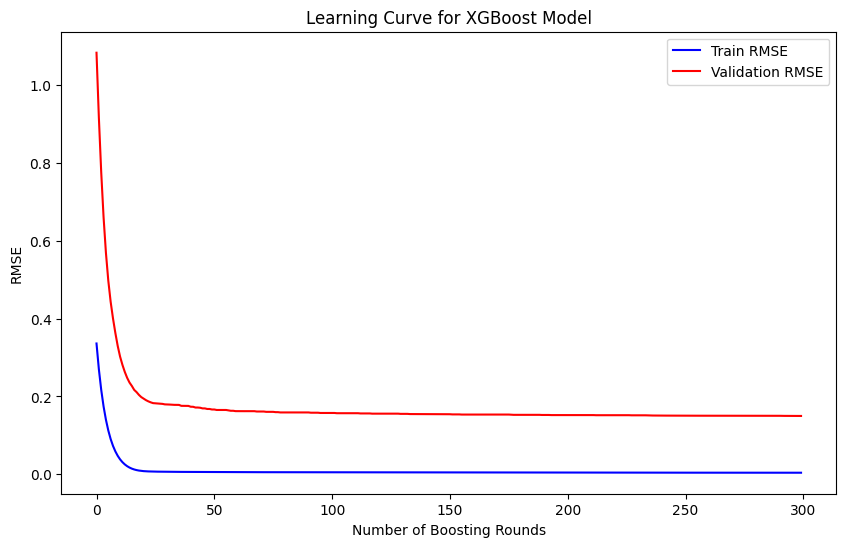

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare DMatrix
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)

# Set the parameters for XGBoost
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 3,
    'learning_rate': 0.2,
    'n_estimators': 300
}

# List of evaluation sets for monitoring
evals = [(dtrain, 'train'), (dval, 'eval')]

# Train the model while storing performance metrics at each boosting round
evals_result = {}  # This will store the evaluation results
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=50,
    evals_result=evals_result,  # Capture the evaluation result
    verbose_eval=False
)

# Plotting the learning curves
plt.figure(figsize=(10, 6))
plt.plot(evals_result['train']['rmse'], label='Train RMSE', color='blue')
plt.plot(evals_result['eval']['rmse'], label='Validation RMSE', color='red')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve for XGBoost Model')
plt.legend(loc='upper right')
plt.show()


###**Cross Validation**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'n_estimators': [100, 200, 300, 400]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=100, cv=3, verbose=2)
random_search.fit(X_train, Y_train)

print(f"Best Hyperparameters: {random_search.best_params_}")


Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=1.0, learning_rate=0.3, max_depth=5, min_child_weight=5, n_estimators=300, subsample=0.6; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.3, max_depth=5, min_child_weight=5, n_estimators=300, subsample=0.6; total time=   1.0s
[CV] END colsample_bytree=1.0, learning_rate=0.3, max_depth=5, min_child_weight=5, n_estimators=300, subsample=0.6; total time=   0.7s
[CV] END colsample_bytree=0.6, learning_rate=0.3, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.3, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.3, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=300, subsample=1.0; total time=

In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Prepare data
dtrain = xgb.DMatrix(X_train, label=Y_train)
dval = xgb.DMatrix(X_val, label=Y_val)
dtest = xgb.DMatrix(X_test, label=Y_test)

# Set parameters for the model
params = {
    'subsample': 0.8,
    'n_estimators': 400,
    'min_child_weight': 1,
    'max_depth': 7,
    'learning_rate': 0.2,
    'colsample_bytree': 0.6,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

# Prepare evals for early stopping
evals = [(dtrain, 'train'), (dval, 'eval')]

# Train the model with early stopping
start_time = time.time()
model = xgb.train(params, dtrain, num_boost_round=1000, evals=evals, early_stopping_rounds=50, verbose_eval=False)
training_time = time.time() - start_time

# Make predictions
train_pred = model.predict(dtrain)
val_pred = model.predict(dval)
test_pred = model.predict(dtest)

# Calculate metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, mse, rmse, r2, mape

# Metrics for Training, Validation, and Test Sets
train_metrics = calculate_metrics(Y_train, train_pred)
val_metrics = calculate_metrics(Y_val, val_pred)
test_metrics = calculate_metrics(Y_test, test_pred)

print(f"Training time: {training_time:.4f} seconds")
print(f"Training Metrics: MAE={train_metrics[0]:.4f}, MSE={train_metrics[1]:.4f}, RMSE={train_metrics[2]:.4f}, R²={train_metrics[3]:.4f}, MAPE={train_metrics[4]:.4f}%")
print(f"Validation Metrics: MAE={val_metrics[0]:.4f}, MSE={val_metrics[1]:.4f}, RMSE={val_metrics[2]:.4f}, R²={val_metrics[3]:.4f}, MAPE={val_metrics[4]:.4f}%")
print(f"Test Metrics: MAE={test_metrics[0]:.4f}, MSE={test_metrics[1]:.4f}, RMSE={test_metrics[2]:.4f}, R²={test_metrics[3]:.4f}, MAPE={test_metrics[4]:.4f}%")


Training time: 0.8974 seconds
Training Metrics: MAE=0.0035, MSE=0.0000, RMSE=0.0052, R²=0.9998, MAPE=1.0612%
Validation Metrics: MAE=0.1214, MSE=0.0200, RMSE=0.1414, R²=-2.3976, MAPE=6.7832%
Test Metrics: MAE=0.3880, MSE=0.1565, RMSE=0.3957, R²=-24.9387, MAPE=19.1245%


Training Set: The model performs excellently on the training data with very low error metrics (MAE, MSE, RMSE, etc.), which suggests overfitting. The R² of 0.9998 means that almost all variance in the training data is explained by the model.

Validation Set: The validation metrics show a notable drop in performance, with a negative R² value (-2.3976), which indicates that the model is not generalizing well to unseen data. The MAPE is lower than the test set, but it’s still considerable.

Test Set: The model struggles on the test data with a high MAE and RMSE, indicating poor predictive performance. The R² is negative (-24.9387), which suggests the model is worse than a simple baseline (mean of the test labels). This is a classic sign of overfitting to the training data, where the model learned noise rather than generalizable patterns.

In [ ]:
!pip install hpbandster


In [ ]:
!pip install hyperopt


In [ ]:
import numpy as np
import xgboost as xgb
from hpbandster.core.worker import Worker
from hpbandster.optimizers import BOHB
from ConfigSpace import ConfigurationSpace
from ConfigSpace.hyperparameters import UniformIntegerHyperparameter, UniformFloatHyperparameter
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
class XGBoostWorker(Worker):
    def compute(self, config, budget, **kwargs):
        # Create the XGBoost model
        model = xgb.XGBRegressor(
            n_estimators=int(config['n_estimators']),
            max_depth=int(config['max_depth']),
            learning_rate=config['learning_rate'],
            gamma=config['gamma'],
            colsample_bytree=config['colsample_bytree'],
            reg_alpha=config['reg_alpha'],
            reg_lambda=config['reg_lambda'],
            objective='reg:squarederror'
        )

        # Train the model
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)

        # Evaluate the model
        y_pred = model.predict(X_val)
        mse = np.mean((y_pred - y_val) ** 2)

        # Return the negative of MSE (since BOHB minimizes)
        return {'loss': mse, 'info': {}}


In [ ]:
def objective_function(config):
    """Objective function for BoHB."""
    model = xgb.XGBRegressor(
        n_estimators=int(config['n_estimators']),
        max_depth=int(config['max_depth']),
        learning_rate=config['learning_rate'],
        gamma=config['gamma'],
        colsample_bytree=config['colsample_bytree'],
        reg_alpha=config['reg_alpha'],
        reg_lambda=config['reg_lambda']
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_val)

    # Evaluate performance using Mean Absolute Error (MAE), RMSE, and R²
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)

    # Return the negative RMSE as the objective for BOHB to minimize
    return {'loss': rmse, 'status': 'ok'}

# Define the configuration space for hyperparameter optimization
config_space = ConfigurationSpace()

# Hyperparameters for XGBoost
n_estimators = UniformIntegerHyperparameter('n_estimators', 100, 1000, log=True)
max_depth = UniformIntegerHyperparameter('max_depth', 1, 10)
learning_rate = UniformFloatHyperparameter('learning_rate', 0.001, 0.1, log=True)
gamma = UniformFloatHyperparameter('gamma', 0.01, 1.0, log=True)
colsample_bytree = UniformFloatHyperparameter('colsample_bytree', 0.5, 1.0)
reg_alpha = UniformFloatHyperparameter('reg_alpha', 0.01, 1.0, log=True)
reg_lambda = UniformFloatHyperparameter('reg_lambda', 0.01, 1.0, log=True)

# Add hyperparameters to the configuration space
config_space.add_hyperparameters([n_estimators, max_depth, learning_rate, gamma, colsample_bytree, reg_alpha, reg_lambda])

# Define the Worker class
class XGBoostWorker(Worker):
    def compute(self, config, budget, **kwargs):
        return objective_function(config)

# Initialize the BOHB optimizer
optimizer = BOHB(configspace=config_space, eta=3, min_budget=1, max_budget=81)

# Run the BOHB optimization
optimizer.run(objective_function, budget=100)

TypeError: Master.__init__() missing 1 required positional argument: 'run_id'

In [ ]:
# Initialize the optimizer with the worker
optimizer = BOHB(config_space=config_space, worker=XGBoostWorker)


ValueError: You have to provide a valid CofigSpace object